In [ ]:
#crispr_carT_AI_analysis/
 #   analysis_utils/
  #      pca_utils.py
   #     preprocessing.py
    #    config_utils.py
   # data/
   # results/
       # pca/

In [43]:
import os, sys

project_root = os.path.expanduser("~/Desktop/crispr_carT_AI_analysis")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from analysis_utils.config_utils import load_config
print("load_config:", load_config)


load_config: <function load_config at 0x30f2fd510>


In [44]:
import os, sys

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from analysis_utils.pca_utils import run_pca_and_save
import pandas as pd


In [45]:
expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

scores_df, loadings_df, explained_df = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)




In [46]:
from pathlib import Path
import sys

project_root = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()

# Make sure the root is on sys.path as a *string*
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("sys.path contains project_root:", str(project_root) in sys.path)

# Test importing the package itself
import analysis_utils
print("analysis_utils module loaded from:", analysis_utils.__file__)


sys.path contains project_root: True
analysis_utils module loaded from: /Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/__init__.py


In [47]:
expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

scores_df, loadings_df, explained_df = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)




In [48]:
import os, sys, pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)

# Ensure project root is on sys.path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from analysis_utils.pca_utils import run_pca_and_save

# Load expression
expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

# Run PCA (safe to re-run; it will just overwrite the same CSVs)
scores_df, loadings_df, explained_df = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)

scores_df.shape, loadings_df.shape, explained_df.shape


((60, 21), (60675, 21), (20, 3))

In [49]:
explained_df


,PC,explained_variance,explained_variance_ratio
0,PC1,9538.302648,0.209814
1,PC2,4838.169930,0.106425
2,PC3,2226.001887,0.048965
3,PC4,1936.650579,0.042601
4,PC5,1228.102172,0.027015
5,PC6,1123.593336,0.024716
6,PC7,911.765757,0.020056
7,PC8,828.016353,0.018214
8,PC9,666.981361,0.014672
9,PC10,639.248830,0.014062


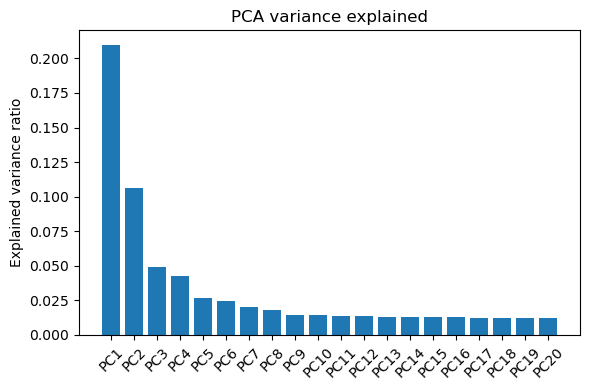

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(explained_df["PC"], explained_df["explained_variance_ratio"])
plt.xticks(rotation=45)
plt.ylabel("Explained variance ratio")
plt.title("PCA variance explained")
plt.tight_layout()
plt.show()


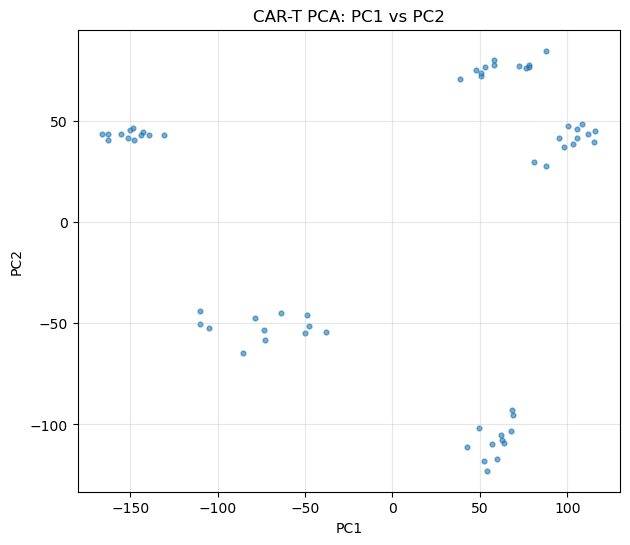

In [51]:
plt.figure(figsize=(7,6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], s=12, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CAR-T PCA: PC1 vs PC2")
plt.grid(True, alpha=0.3)
plt.show()


In [52]:
scores_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q1    24
Q2    12
Q3    12
Q4    12
Name: count, dtype: int64

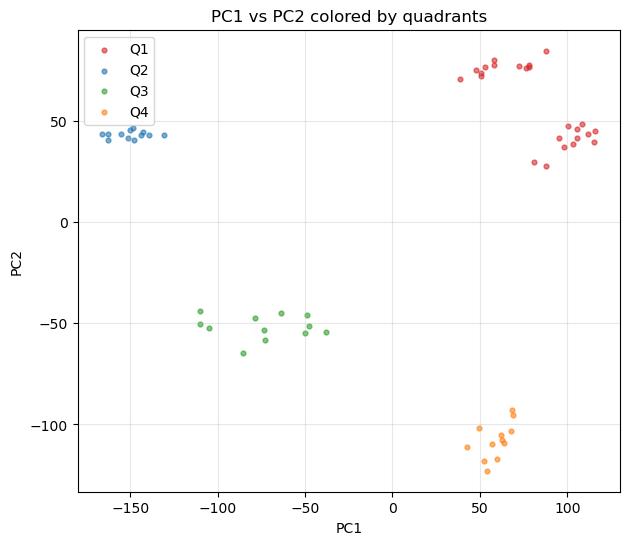

In [53]:
import matplotlib.pyplot as plt

colors = {
    "Q1": "tab:red",
    "Q2": "tab:blue",
    "Q3": "tab:green",
    "Q4": "tab:orange",
}

plt.figure(figsize=(7,6))
for quad, sub in scores_df.groupby("quadrant_PC1_PC2"):
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=12,
        alpha=0.6,
        label=quad,
        c=colors.get(quad, "grey"),
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by quadrants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [54]:
def top_genes(loadings_df, pc, n=20):
    return loadings_df[pc].sort_values(ascending=False).head(n)

def bottom_genes(loadings_df, pc, n=20):
    return loadings_df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene
 ENSG00000213983    0.010232
 ENSG00000146083    0.010216
 ENSG00000185862    0.010209
 ENSG00000163346    0.010204
 ENSG00000100242    0.010191
 ENSG00000047346    0.010191
 ENSG00000104894    0.010177
 ENSG00000010295    0.010159
 ENSG00000267680    0.010151
 ENSG00000064687    0.010140
 ENSG00000112406    0.010134
 ENSG00000174282    0.010132
 ENSG00000137070    0.010126
 ENSG00000015133    0.010125
 ENSG00000078304    0.010124
 ENSG00000187650    0.010116
 ENSG00000211787    0.010112
 ENSG00000139436    0.010108
 ENSG00000012822    0.010108
 ENSG00000178537    0.010100
 Name: PC1, dtype: float64,
 gene
 ENSG00000161671    0.014225
 ENSG00000104679    0.014183
 ENSG00000155636    0.014153
 ENSG00000124160    0.014116
 ENSG00000149182    0.014069
 ENSG00000254901    0.014066
 ENSG00000100478    0.014053
 ENSG00000153914    0.014051
 ENSG00000183155    0.014048
 ENSG00000101096    0.014038
 ENSG00000137776    0.014029
 ENSG00000105127    0.013957
 ENSG00000148719    0.013954
 EN

In [55]:
loadings_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q1    28330
Q2    13365
Q3    10153
Q4     8827
Name: count, dtype: int64

In [56]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q1[:30]


['ENSG00000243485',
 'ENSG00000239945',
 'ENSG00000233750',
 'ENSG00000241599',
 'ENSG00000279928',
 'ENSG00000273874',
 'ENSG00000230021',
 'ENSG00000235146',
 'ENSG00000225972',
 'ENSG00000229344',
 'ENSG00000268663',
 'ENSG00000284662',
 'ENSG00000229376',
 'ENSG00000228327',
 'ENSG00000223181',
 'ENSG00000229905',
 'ENSG00000237491',
 'ENSG00000285268',
 'ENSG00000230092',
 'ENSG00000177757',
 'ENSG00000225880',
 'ENSG00000288531',
 'ENSG00000234711',
 'ENSG00000283040',
 'ENSG00000187961',
 'ENSG00000187608',
 'ENSG00000224969',
 'ENSG00000242590',
 'ENSG00000207607',
 'ENSG00000131584']

In [62]:
import pandas as pd

map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

ensg_map.head()


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [63]:
ensg_to_symbol = dict(zip(ensg_map.iloc[:,0], ensg_map.iloc[:,1]))


In [64]:
index = ENSG00000223972, ENSG00000227232, …


SyntaxError: invalid character '…' (U+2026) (2370386953.py, line 1)

In [65]:
loadings_df = loadings_df.copy()
loadings_df["gene_symbol"] = loadings_df.index.map(ensg_to_symbol).fillna(loadings_df.index)
loadings_df = loadings_df.set_index("gene_symbol")


TypeError: 'value' must be a scalar, passed: Index

In [66]:
scores_df.index = scores_df.index.map(lambda x: x)   # samples stay same
loadings_df.index = loadings_df.index.map(str)       # already converted above


In [67]:
loadings_df["PC1"].sort_values(ascending=False).head(20)


gene
ENSG00000213983    0.010232
ENSG00000146083    0.010216
ENSG00000185862    0.010209
ENSG00000163346    0.010204
ENSG00000100242    0.010191
ENSG00000047346    0.010191
ENSG00000104894    0.010177
ENSG00000010295    0.010159
ENSG00000267680    0.010151
ENSG00000064687    0.010140
ENSG00000112406    0.010134
ENSG00000174282    0.010132
ENSG00000137070    0.010126
ENSG00000015133    0.010125
ENSG00000078304    0.010124
ENSG00000187650    0.010116
ENSG00000211787    0.010112
ENSG00000139436    0.010108
ENSG00000012822    0.010108
ENSG00000178537    0.010100
Name: PC1, dtype: float64

In [68]:
import pandas as pd

map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

print(ensg_map.columns)
ensg_map.head()


Index(['ensembl', 'symbol'], dtype='object')


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [69]:
cols = [c.lower() for c in ensg_map.columns]
print("Columns (lowercased):", cols)

# Pick the ENSG/Ensembl column
ensg_col = None
for c in ensg_map.columns:
    cl = c.lower()
    if "ensg" in cl or "ensembl" in cl or "gene_id" in cl:
        ensg_col = c
        break

# Pick the symbol column
sym_col = None
for c in ensg_map.columns:
    cl = c.lower()
    if "symbol" in cl or "gene_name" in cl or (("name" in cl or "symbol" in cl) and "gene" in cl):
        sym_col = c
        break

print("Using columns:", ensg_col, "→", sym_col)


Columns (lowercased): ['ensembl', 'symbol']
Using columns: ensembl → symbol


In [70]:
def strip_version(x):
    # Turn 'ENSG00000123456.5' -> 'ENSG00000123456'
    return str(x).split(".")[0]

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}


In [71]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if missing

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")


In [72]:
loadings_df.head()
loadings_df["PC1"].sort_values(ascending=False).head(20)


gene_symbol
AP1G2       0.010232
RNF44       0.010216
EVI2B       0.010209
PBXIP1      0.010204
SUN2        0.010191
ATOSA       0.010191
CD37        0.010177
IFFO1       0.010159
ZNF224      0.010151
ABCA7       0.010140
HECA        0.010134
ZBTB4       0.010132
IL11RA      0.010126
CCDC88C     0.010125
PPP2R5C     0.010124
VMAC        0.010116
TRAV8-3     0.010112
GIT2        0.010108
CALCOCO1    0.010108
SLC25A20    0.010100
Name: PC1, dtype: float64

In [73]:
loadings_df["PC1"].sort_values(ascending=False).head(20)

gene_symbol
AP1G2       0.010232
RNF44       0.010216
EVI2B       0.010209
PBXIP1      0.010204
SUN2        0.010191
ATOSA       0.010191
CD37        0.010177
IFFO1       0.010159
ZNF224      0.010151
ABCA7       0.010140
HECA        0.010134
ZBTB4       0.010132
IL11RA      0.010126
CCDC88C     0.010125
PPP2R5C     0.010124
VMAC        0.010116
TRAV8-3     0.010112
GIT2        0.010108
CALCOCO1    0.010108
SLC25A20    0.010100
Name: PC1, dtype: float64

In [74]:
import pandas as pd

# 1. Load mapping
map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

print("Mapping columns:", ensg_map.columns)
ensg_map.head()


Mapping columns: Index(['ensembl', 'symbol'], dtype='object')


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [75]:
# Helper to strip version suffix: ENSG00000123456.5 → ENSG00000123456
def strip_version(x):
    return str(x).split(".")[0]

# Infer which columns hold ENSG IDs and symbols
ensg_col = None
sym_col = None

for c in ensg_map.columns:
    cl = c.lower()
    if any(tok in cl for tok in ["ensg", "ensembl", "gene_id"]):
        ensg_col = c
    if any(tok in cl for tok in ["symbol", "gene_name", "gene symbol"]):
        sym_col = c

print("Using mapping:", ensg_col, "→", sym_col)

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}
len(ensg_to_symbol)


Using mapping: ensembl → symbol


46920

In [76]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if not found

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")

loadings_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,quadrant_PC1_PC2
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,-8.988885e-04,4.619980e-03,-4.711130e-03,1.696339e-03,-4.134735e-04,-2.137106e-03,-7.915692e-03,-1.932126e-03,-5.513443e-04,5.369664e-03,...,8.145249e-03,-3.273621e-03,8.714028e-04,1.282659e-02,-6.017677e-03,2.865543e-03,-9.714152e-04,-1.315221e-02,-2.403890e-03,Q2
WASH7P,5.963675e-03,-6.779471e-04,-6.143735e-03,3.574448e-03,-9.349886e-03,-4.857401e-03,-1.771119e-02,-3.358396e-03,-1.494046e-04,2.072323e-03,...,3.896419e-03,1.631868e-03,-1.677884e-03,6.642102e-04,3.505871e-04,-2.875594e-03,1.088253e-03,1.148120e-03,3.173192e-03,Q4
MIR6859-1,3.407487e-03,-3.700457e-03,-4.545203e-03,7.507743e-03,-2.521390e-03,-4.938558e-03,-4.889862e-03,-6.768714e-03,-2.016945e-04,1.270341e-03,...,2.107655e-03,-1.253725e-03,-8.201538e-03,-8.401363e-03,-7.116697e-03,3.302319e-03,6.361610e-03,-5.046665e-03,-4.954174e-04,Q4
MIR1302-2HG,1.087096e-03,2.116578e-03,5.940839e-04,-3.524667e-03,3.099436e-03,-2.138195e-03,-1.287571e-03,-1.916921e-05,-1.646981e-03,-2.015423e-03,...,-1.311890e-03,-5.304674e-03,6.719490e-03,3.884234e-03,1.208045e-03,4.459771e-03,3.142794e-04,-3.987224e-03,1.314223e-03,Q1
MIR1302-2,-1.655409e-18,-2.060223e-17,-1.555119e-16,-2.090655e-16,7.529774e-15,8.626381e-15,5.560998e-15,1.848533e-16,1.376956e-14,4.882524e-15,...,-1.212176e-14,-1.129329e-15,2.113101e-14,-6.996244e-15,3.477687e-15,-7.948554e-15,8.104150e-15,-6.627247e-16,3.622208e-15,Q3


In [77]:
def top_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=False).head(n)

def bottom_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene_symbol
 AP1G2       0.010232
 RNF44       0.010216
 EVI2B       0.010209
 PBXIP1      0.010204
 SUN2        0.010191
 ATOSA       0.010191
 CD37        0.010177
 IFFO1       0.010159
 ZNF224      0.010151
 ABCA7       0.010140
 HECA        0.010134
 ZBTB4       0.010132
 IL11RA      0.010126
 CCDC88C     0.010125
 PPP2R5C     0.010124
 VMAC        0.010116
 TRAV8-3     0.010112
 GIT2        0.010108
 CALCOCO1    0.010108
 SLC25A20    0.010100
 Name: PC1, dtype: float64,
 gene_symbol
 EMC10        0.014225
 R3HCC1       0.014183
 RBM45        0.014153
 NCOA5        0.014116
 ARFGAP2      0.014069
 BORCS8       0.014066
 AP4S1        0.014053
 SREK1        0.014051
 RABIF        0.014048
 NFATC2       0.014038
 SLTM         0.014029
 AKAP8        0.013957
 DNAJB12      0.013954
 SECISBP2     0.013950
 ZNF75A       0.013950
 CHMP6        0.013949
 C1orf216     0.013922
 LINC00680    0.013922
 IFT88        0.013920
 MCRS1        0.013919
 Name: PC2, dtype: float64)

In [78]:
# Helper to strip version suffix: ENSG00000123456.5 → ENSG00000123456
def strip_version(x):
    return str(x).split(".")[0]

# Infer which columns hold ENSG IDs and symbols
ensg_col = None
sym_col = None

for c in ensg_map.columns:
    cl = c.lower()
    if any(tok in cl for tok in ["ensg", "ensembl", "gene_id"]):
        ensg_col = c
    if any(tok in cl for tok in ["symbol", "gene_name", "gene symbol"]):
        sym_col = c

print("Using mapping:", ensg_col, "→", sym_col)

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}
len(ensg_to_symbol)


Using mapping: ensembl → symbol


46920

In [79]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if not found

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")

loadings_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,quadrant_PC1_PC2
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,-8.988885e-04,4.619980e-03,-4.711130e-03,1.696339e-03,-4.134735e-04,-2.137106e-03,-7.915692e-03,-1.932126e-03,-5.513443e-04,5.369664e-03,...,8.145249e-03,-3.273621e-03,8.714028e-04,1.282659e-02,-6.017677e-03,2.865543e-03,-9.714152e-04,-1.315221e-02,-2.403890e-03,Q2
WASH7P,5.963675e-03,-6.779471e-04,-6.143735e-03,3.574448e-03,-9.349886e-03,-4.857401e-03,-1.771119e-02,-3.358396e-03,-1.494046e-04,2.072323e-03,...,3.896419e-03,1.631868e-03,-1.677884e-03,6.642102e-04,3.505871e-04,-2.875594e-03,1.088253e-03,1.148120e-03,3.173192e-03,Q4
MIR6859-1,3.407487e-03,-3.700457e-03,-4.545203e-03,7.507743e-03,-2.521390e-03,-4.938558e-03,-4.889862e-03,-6.768714e-03,-2.016945e-04,1.270341e-03,...,2.107655e-03,-1.253725e-03,-8.201538e-03,-8.401363e-03,-7.116697e-03,3.302319e-03,6.361610e-03,-5.046665e-03,-4.954174e-04,Q4
MIR1302-2HG,1.087096e-03,2.116578e-03,5.940839e-04,-3.524667e-03,3.099436e-03,-2.138195e-03,-1.287571e-03,-1.916921e-05,-1.646981e-03,-2.015423e-03,...,-1.311890e-03,-5.304674e-03,6.719490e-03,3.884234e-03,1.208045e-03,4.459771e-03,3.142794e-04,-3.987224e-03,1.314223e-03,Q1
MIR1302-2,-1.655409e-18,-2.060223e-17,-1.555119e-16,-2.090655e-16,7.529774e-15,8.626381e-15,5.560998e-15,1.848533e-16,1.376956e-14,4.882524e-15,...,-1.212176e-14,-1.129329e-15,2.113101e-14,-6.996244e-15,3.477687e-15,-7.948554e-15,8.104150e-15,-6.627247e-16,3.622208e-15,Q3


In [80]:
def top_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=False).head(n)

def bottom_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene_symbol
 AP1G2       0.010232
 RNF44       0.010216
 EVI2B       0.010209
 PBXIP1      0.010204
 SUN2        0.010191
 ATOSA       0.010191
 CD37        0.010177
 IFFO1       0.010159
 ZNF224      0.010151
 ABCA7       0.010140
 HECA        0.010134
 ZBTB4       0.010132
 IL11RA      0.010126
 CCDC88C     0.010125
 PPP2R5C     0.010124
 VMAC        0.010116
 TRAV8-3     0.010112
 GIT2        0.010108
 CALCOCO1    0.010108
 SLC25A20    0.010100
 Name: PC1, dtype: float64,
 gene_symbol
 EMC10        0.014225
 R3HCC1       0.014183
 RBM45        0.014153
 NCOA5        0.014116
 ARFGAP2      0.014069
 BORCS8       0.014066
 AP4S1        0.014053
 SREK1        0.014051
 RABIF        0.014048
 NFATC2       0.014038
 SLTM         0.014029
 AKAP8        0.013957
 DNAJB12      0.013954
 SECISBP2     0.013950
 ZNF75A       0.013950
 CHMP6        0.013949
 C1orf216     0.013922
 LINC00680    0.013922
 IFT88        0.013920
 MCRS1        0.013919
 Name: PC2, dtype: float64)

In [81]:
loadings_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q1    28330
Q2    13365
Q3    10153
Q4     8827
Name: count, dtype: int64

In [82]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q2 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q2"].index.tolist()
genes_q3 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q3"].index.tolist()
genes_q4 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q4"].index.tolist()

genes_q1[:20]


['MIR1302-2HG',
 'ENSG00000239945',
 'CICP27',
 'ENSG00000241599',
 'DDX11L17',
 'MIR6859-2',
 'ENSG00000230021',
 'ENSG00000235146',
 'MTND1P23',
 'MTCO2P12',
 'WBP1LP6',
 'OR4F16',
 'CICP3',
 'ENSG00000228327',
 'RNU6-1199P',
 'ENSG00000229905',
 'LINC01409',
 'ENSG00000285268',
 'ENSG00000230092',
 'FAM87B']

In [83]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q1[:20]

['MIR1302-2HG',
 'ENSG00000239945',
 'CICP27',
 'ENSG00000241599',
 'DDX11L17',
 'MIR6859-2',
 'ENSG00000230021',
 'ENSG00000235146',
 'MTND1P23',
 'MTCO2P12',
 'WBP1LP6',
 'OR4F16',
 'CICP3',
 'ENSG00000228327',
 'RNU6-1199P',
 'ENSG00000229905',
 'LINC01409',
 'ENSG00000285268',
 'ENSG00000230092',
 'FAM87B']

In [84]:
top_pc1 = loadings_df["PC1"].sort_values(ascending=False).head(30)
bot_pc1 = loadings_df["PC1"].sort_values(ascending=True).head(30)

top_pc2 = loadings_df["PC2"].sort_values(ascending=False).head(30)
bot_pc2 = loadings_df["PC2"].sort_values(ascending=True).head(30)

top_pc1, top_pc2


(gene_symbol
 AP1G2        0.010232
 RNF44        0.010216
 EVI2B        0.010209
 PBXIP1       0.010204
 SUN2         0.010191
 ATOSA        0.010191
 CD37         0.010177
 IFFO1        0.010159
 ZNF224       0.010151
 ABCA7        0.010140
 HECA         0.010134
 ZBTB4        0.010132
 IL11RA       0.010126
 CCDC88C      0.010125
 PPP2R5C      0.010124
 VMAC         0.010116
 TRAV8-3      0.010112
 GIT2         0.010108
 CALCOCO1     0.010108
 SLC25A20     0.010100
 VAMP2        0.010098
 SERINC3      0.010095
 GPR15        0.010089
 DPEP2        0.010088
 LRP10        0.010084
 LINC00324    0.010083
 NISCH        0.010082
 TRBC1        0.010081
 CAPS         0.010079
 PIK3IP1      0.010078
 Name: PC1, dtype: float64,
 gene_symbol
 EMC10        0.014225
 R3HCC1       0.014183
 RBM45        0.014153
 NCOA5        0.014116
 ARFGAP2      0.014069
 BORCS8       0.014066
 AP4S1        0.014053
 SREK1        0.014051
 RABIF        0.014048
 NFATC2       0.014038
 SLTM         0.014029
 AK

In [85]:
top_pc3 = loadings_df["PC3"].sort_values(ascending=False).head(30)
top_pc4 = loadings_df["PC4"].sort_values(ascending=False).head(30)

top_pc3, top_pc4


(gene_symbol
 SAPCD2       0.019860
 KIF11        0.019740
 TMOD3        0.019523
 PDS5B        0.019364
 AKT1         0.019171
 GTSE1        0.019164
 ARHGAP11A    0.019115
 LMNB1        0.019113
 SMC4         0.019086
 CEP55        0.018973
 SKA2         0.018916
 KNL1         0.018894
 RECQL        0.018862
 NDC80        0.018835
 RAD21        0.018736
 H2AZ2        0.018695
 NUDT1        0.018677
 H2AX         0.018628
 TAF3         0.018507
 HMGB1        0.018501
 SAP18        0.018430
 FAM83D       0.018403
 RBM10        0.018345
 GNB2         0.018319
 CBFB         0.018269
 PPM1D        0.018268
 EBP          0.018258
 TMPO-AS1     0.018203
 MKI67        0.018163
 PPP6R1       0.018127
 Name: PC3, dtype: float64,
 gene_symbol
 CCAR1       0.020925
 RPS19BP1    0.020685
 YKT6        0.020558
 EDC4        0.020402
 NUBP2       0.020190
 NEURL4      0.019870
 BRAP        0.019817
 MSTO2P      0.019798
 NDOR1       0.019738
 DDX51       0.019726
 SMG5        0.019647
 SLC30A1     0

In [86]:
explained_df


,PC,explained_variance,explained_variance_ratio
0,PC1,9538.302648,0.209814
1,PC2,4838.169930,0.106425
2,PC3,2226.001887,0.048965
3,PC4,1936.650579,0.042601
4,PC5,1228.102172,0.027015
5,PC6,1123.593336,0.024716
6,PC7,911.765757,0.020056
7,PC8,828.016353,0.018214
8,PC9,666.981361,0.014672
9,PC10,639.248830,0.014062


In [87]:
top_pc5 = loadings_df["PC5"].sort_values(ascending=False).head(30)
top_pc6 = loadings_df["PC6"].sort_values(ascending=False).head(30)

top_pc5, top_pc6


(gene_symbol
 IKZF2          0.024434
 DBN1           0.023976
 NECTIN3        0.023870
 TTC24          0.022498
 SLC35D1        0.022292
 PTCH1          0.022243
 VAV3           0.022196
 CD8A           0.021802
 CLDND2         0.021796
 CD63           0.021586
 PRF1           0.021399
 TSPAN5         0.021341
 KLRK1          0.021041
 CD8B           0.020974
 KLRD1          0.020799
 KLRC4-KLRK1    0.020792
 HOPX           0.020764
 LINC02446      0.020749
 KLRC4          0.020688
 ANAPC1P1       0.020622
 LINC02598      0.020510
 GAS7           0.020483
 RGS3           0.020360
 NCR2           0.020290
 STYK1          0.020226
 PTPN7          0.020158
 RIN3           0.020102
 NKG7           0.019980
 KLRC1          0.019950
 PROX2          0.019701
 Name: PC5, dtype: float64,
 gene_symbol
 RAB34              0.021763
 GUCY1B1            0.021141
 ANK3               0.020778
 ZNF219             0.020097
 CDV3               0.019018
 GPX1P1             0.019016
 CCR4               0.

In [88]:
#Assign quadrants for PC5–PC6
from analysis_utils.pca_utils import assign_quadrant

scores_p5p6 = scores_df.copy()

scores_p5p6["quadrant_PC5_PC6"] = [
    assign_quadrant(x, y) for x, y in zip(scores_p5p6["PC5"], scores_p5p6["PC6"])
]

scores_p5p6["quadrant_PC5_PC6"].value_counts()


quadrant_PC5_PC6
Q2    19
Q4    16
Q1    13
Q3    12
Name: count, dtype: int64

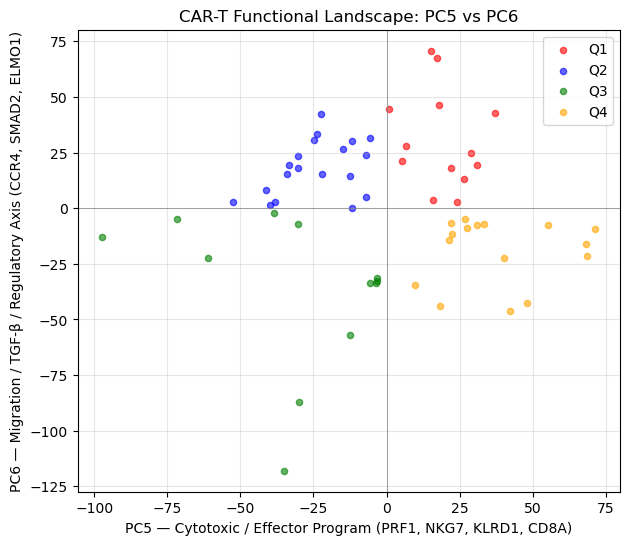

In [89]:
import matplotlib.pyplot as plt

color_map = {
    "Q1": "red",      # effector + regulatory
    "Q2": "blue",     # low effector, high regulatory
    "Q3": "green",    # double-low (resting / naive-like)
    "Q4": "orange",   # high effector, low regulatory
}

plt.figure(figsize=(7,6))
for quad, sub in scores_p5p6.groupby("quadrant_PC5_PC6"):
    plt.scatter(
        sub["PC5"], sub["PC6"],
        label=quad,
        c=color_map[quad],
        s=20,
        alpha=0.6,
    )

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("PC5 — Cytotoxic / Effector Program (PRF1, NKG7, KLRD1, CD8A)")
plt.ylabel("PC6 — Migration / TGF-β / Regulatory Axis (CCR4, SMAD2, ELMO1)")
plt.title("CAR-T Functional Landscape: PC5 vs PC6")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [90]:
#Compute marker expression per quadrant (so you can see 
#the biology)
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

marker_expr = expr_logcpm.loc[markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()


KeyError: "None of [Index(['PRF1', 'GZMB', 'IFNG', 'TNF', 'CD8A', 'CD8B', 'CCR7', 'TCF7', 'IL7R',\n       'SMAD2', 'CCR4'],\n      dtype='object', name='gene')] are in the [index]"

In [91]:
import gseapy as gp

quadrant_genes = {}
for quad in ["Q1","Q2","Q3","Q4"]:
    # take top 300 genes by loading (biologically cleaner than DE)
    quad_genes = loadings_df.sort_values(by="PC5", ascending=(quad in ["Q2","Q3"])).index[:300]
    quadrant_genes[quad] = quad_genes

# Run enrichment for each quadrant
enrichments = {}
for quad, genes in quadrant_genes.items():
    enr = gp.enrichr(
        gene_list=list(genes),
        gene_sets="MSigDB_Hallmark_2020",
        organism="human",
    )
    enrichments[quad] = enr.results

enrichments["Q4"].head(10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Allograft Rejection,9/200,0.003317,0.122725,0,0,3.159011,18.033939,NCR1;CD8B;CD8A;CCL5;GCNT1;PRF1;KLRD1;FASLG;PTPN6
1,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,7/199,0.030900,0.553937,0,0,2.427403,8.440105,EOMES;GABARAPL1;CDCP1;PTCH1;LRRC8C;IKZF2;HOPX
2,MSigDB_Hallmark_2020,Coagulation,5/138,0.057139,0.553937,0,0,2.493564,7.137252,BMP1;USP11;PLEK;HTRA1;PECAM1
3,MSigDB_Hallmark_2020,Interferon Gamma Response,6/200,0.081377,0.553937,0,0,2.051967,5.147687,KLRK1;P2RY14;CCL5;SLAMF7;PTPN6;GPR18
4,MSigDB_Hallmark_2020,Apical Junction,6/200,0.081377,0.553937,0,0,2.051967,5.147687,TRO;BMP1;CERCAM;PECAM1;NECTIN3;SKAP2
5,MSigDB_Hallmark_2020,Fatty Acid Metabolism,5/158,0.089828,0.553937,0,0,2.165393,5.218299,UGDH;GABARAPL1;CA6;MLYCD;ADIPOR2
6,MSigDB_Hallmark_2020,Apical Surface,2/44,0.141003,0.745300,0,0,3.141259,6.153651,AFAP1L2;ADIPOR2
7,MSigDB_Hallmark_2020,Estrogen Response Late,5/200,0.182596,0.844505,0,0,1.695350,2.882911,UGDH;SLC24A3;TST;PTPN6;PDZK1
8,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,3/105,0.209067,0.859498,0,0,1.940780,3.037515,VAV3;SLA;FASLG
9,MSigDB_Hallmark_2020,Myogenesis,4/200,0.352744,0.888929,0,0,1.344732,1.401229,NCAM1;AEBP1;PDLIM7;EPHB3


In [92]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = scores_df[["PC5","PC6"]]
y = scores_p5p6["quadrant_PC5_PC6"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))


Accuracy: 0.9333333333333333


In [94]:
# assuming ensg_to_symbol and strip_version() already defined earlier

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if missing

expr_symbol = expr_logcpm.copy()
expr_symbol["gene_symbol"] = expr_symbol.index.map(map_ensg_to_symbol)

# avoid duplicated symbols: keep first occurrence
expr_symbol = expr_symbol[~expr_symbol["gene_symbol"].duplicated()]

expr_symbol = expr_symbol.set_index("gene_symbol")

expr_symbol.head()


,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0.000000,0.000000,0.000000,0.027546,0.072575,0.135813,0.000000,0.104961,0.000000,0.000000,...,0.033319,0.032842,0.042139,0.145059,0.108522,0.039193,0.037302,0.031317,0.000000,0.063063
WASH7P,1.976637,2.143149,1.518306,1.814642,2.093505,2.333105,1.667199,1.915681,1.249409,1.441141,...,1.642336,1.764934,2.226080,2.276448,2.068884,1.995439,1.819509,1.538674,2.230874,2.087243
MIR6859-1,0.233659,0.084208,0.108840,0.246303,0.172425,0.341679,0.199822,0.000000,0.091396,0.064387,...,0.156490,0.154383,0.387592,0.241524,0.350874,0.246703,0.322127,0.091153,0.156030,0.178381
MIR1302-2HG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153805,...,0.033319,0.000000,0.000000,0.075157,0.000000,0.113252,0.000000,0.000000,0.000000,0.000000
MIR1302-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [95]:
for g in ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]:
    print(g, g in expr_symbol.index)


PRF1 True
GZMB True
IFNG True
TNF True
CD8A True
CD8B True
CCR7 True
TCF7 True
IL7R True
SMAD2 True
CCR4 True


In [96]:
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

available_markers = [g for g in markers if g in expr_symbol.index]
print("Found markers:", available_markers)

marker_expr = expr_symbol.loc[available_markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()



Found markers: ['PRF1', 'GZMB', 'IFNG', 'TNF', 'CD8A', 'CD8B', 'CCR7', 'TCF7', 'IL7R', 'SMAD2', 'CCR4']


gene_symbol,PRF1,GZMB,IFNG,TNF,CD8A,CD8B,CCR7,TCF7,IL7R,SMAD2,CCR4
quadrant,,,,,,,,,,,
Q1,6.221725,8.460343,8.348475,5.662281,5.612083,3.648086,6.148590,2.655691,2.405822,4.960056,5.338628
Q2,5.802697,5.679104,4.482819,4.383184,3.439319,1.939928,4.123008,3.329641,4.209389,4.860336,4.930693
Q3,5.943519,7.022472,7.021532,4.934743,5.481866,3.875734,4.637352,2.804410,3.549213,4.716886,4.709757
Q4,6.779527,6.382860,4.435452,4.156081,7.333863,5.835889,2.659314,3.007101,3.177618,4.849565,3.530868


In [97]:
top_pc7 = loadings_df["PC7"].sort_values(ascending=False).head(30)
top_pc8 = loadings_df["PC8"].sort_values(ascending=False).head(30)

top_pc7, top_pc8


(gene_symbol
 ENSG00000225178    0.030446
 RPSAP47            0.030026
 RPL13P12           0.029954
 SLC30A8            0.029724
 NMNAT3             0.029186
 PKD1P5             0.028869
 CADM2              0.028755
 AGBL3              0.028723
 ENSG00000267533    0.028413
 BTNL12P            0.028368
 WASHC1             0.028091
 NSFP1              0.027518
 METTL27            0.027420
 ENSG00000261613    0.027196
 HYAL4              0.026953
 GGT2P              0.026940
 ENSG00000288107    0.026885
 RPS26              0.026641
 HAAO               0.026620
 ENSG00000196656    0.026483
 HLA-J              0.026099
 ENSG00000219201    0.025905
 RPL10P9            0.025805
 TPSB2              0.025802
 GGT3P              0.025733
 TPSAB1             0.025721
 SLC44A5            0.025661
 ENSG00000250658    0.025405
 NBPF3              0.025174
 SNHG5              0.024901
 Name: PC7, dtype: float64,
 gene_symbol
 ZFP28              0.024046
 NPIPA5             0.023272
 XIST             

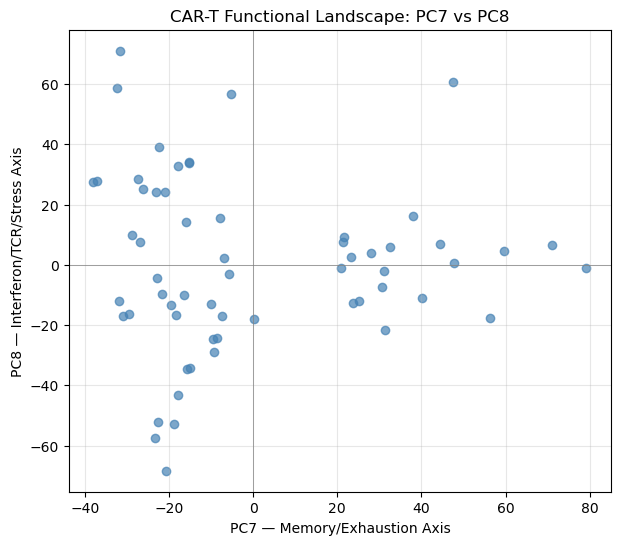

In [98]:
plt.figure(figsize=(7,6))
plt.scatter(scores_df["PC7"], scores_df["PC8"], c="steelblue", alpha=0.7)
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("PC7 — Memory/Exhaustion Axis")
plt.ylabel("PC8 — Interferon/TCR/Stress Axis")
plt.title("CAR-T Functional Landscape: PC7 vs PC8")
plt.grid(alpha=0.3)
plt.show()


In [99]:
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

available_markers = [g for g in markers if g in expr_symbol.index]
print("Found markers:", available_markers)

marker_expr = expr_symbol.loc[available_markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()


Found markers: ['PRF1', 'GZMB', 'IFNG', 'TNF', 'CD8A', 'CD8B', 'CCR7', 'TCF7', 'IL7R', 'SMAD2', 'CCR4']


gene_symbol,PRF1,GZMB,IFNG,TNF,CD8A,CD8B,CCR7,TCF7,IL7R,SMAD2,CCR4
quadrant,,,,,,,,,,,
Q1,6.221725,8.460343,8.348475,5.662281,5.612083,3.648086,6.148590,2.655691,2.405822,4.960056,5.338628
Q2,5.802697,5.679104,4.482819,4.383184,3.439319,1.939928,4.123008,3.329641,4.209389,4.860336,4.930693
Q3,5.943519,7.022472,7.021532,4.934743,5.481866,3.875734,4.637352,2.804410,3.549213,4.716886,4.709757
Q4,6.779527,6.382860,4.435452,4.156081,7.333863,5.835889,2.659314,3.007101,3.177618,4.849565,3.530868


In [100]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Features and labels
X = scores_df[["PC5", "PC6"]]
y = scores_p5p6["quadrant_PC5_PC6"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42)),
])

clf.fit(X_train, y_train)

print("Test accuracy:", clf.score(X_test, y_test))
print()
print("Confusion matrix:\n", confusion_matrix(y_test, clf.predict(X_test)))
print()
print(classification_report(y_test, clf.predict(X_test)))


Test accuracy: 0.9333333333333333

Confusion matrix:
 [[2 0 0 1]
 [0 5 0 0]
 [0 0 3 0]
 [0 0 0 4]]

              precision    recall  f1-score   support

          Q1       1.00      0.67      0.80         3
          Q2       1.00      1.00      1.00         5
          Q3       1.00      1.00      1.00         3
          Q4       0.80      1.00      0.89         4

    accuracy                           0.93        15
   macro avg       0.95      0.92      0.92        15
weighted avg       0.95      0.93      0.93        15



In [101]:
import joblib

def train_quadrant_classifier(scores_df, labels, out_path=None):
    X = scores_df[["PC5", "PC6"]]
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42)),
    ])
    clf.fit(X_train, y_train)

    print("Test accuracy:", clf.score(X_test, y_test))

    if out_path is not None:
        joblib.dump(clf, out_path)
        print("Saved classifier to:", out_path)

    return clf

quadrant_labels = scores_p5p6["quadrant_PC5_PC6"]
quadrant_clf = train_quadrant_classifier(
    scores_df, quadrant_labels,
    out_path="results/pca/quadrant_classifier_PC5_PC6.joblib"
)


Test accuracy: 0.9333333333333333
Saved classifier to: results/pca/quadrant_classifier_PC5_PC6.joblib


In [ ]:
import joblib

clf_loaded = joblib.load("results/pca/quadrant_classifier_PC5_PC6.joblib")

# new_scores_df must have columns PC5 and PC6
pred_quadrants = clf_loaded.predict(new_scores_df[["PC5", "PC6"]])
pred_probs     = clf_loaded.predict_proba(new_scores_df[["PC5", "PC6"]])

pred_quadrants
